<a href="https://colab.research.google.com/github/2023giteshpeswani/MLDL-EXPS/blob/main/MLDL_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_927/1973482533.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 37.2k/37.2k [00:00<00:00, 26.2MB/s]

Dataset Shape: (1025, 14)

First 5 records:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

===== KNN (K=5) =====
Accuracy: 0.8341463414634146

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.

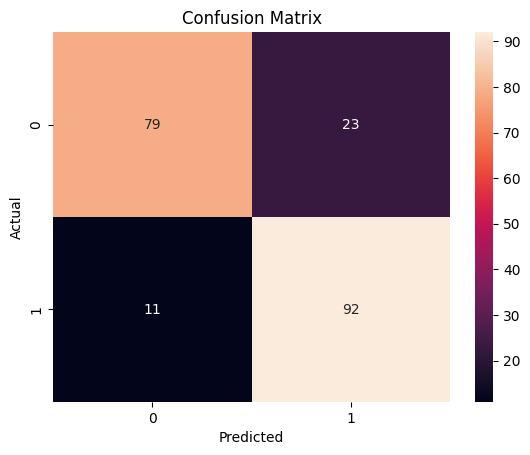


===== FINDING BEST K =====


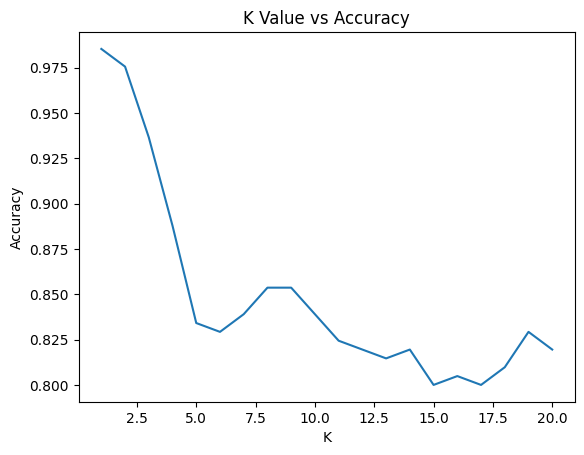

Best K Value: 1


In [ ]:
# Install dependency
!pip install kagglehub[pandas-datasets]

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================
# STEP 1: LOAD DATASET
# ============================
file_path = "heart.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "johnsmith88/heart-disease-dataset",
    file_path
)

print("Dataset Shape:", df.shape)
print("\nFirst 5 records:\n", df.head())

# ============================
# STEP 2: PREPROCESSING
# ============================
# Features & Target
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling (VERY IMPORTANT for KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ============================
# STEP 3: TRAIN-TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# STEP 4: KNN MODEL (K=5)
# ============================
print("\n===== KNN (K=5) =====")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ============================
# STEP 5: CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================
# STEP 6: FIND BEST K
# ============================
print("\n===== FINDING BEST K =====")

accuracy_list = []
k_range = range(1, 21)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred_k))

plt.figure()
plt.plot(k_range, accuracy_list)
plt.title("K Value vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

best_k = k_range[accuracy_list.index(max(accuracy_list))]
print("Best K Value:", best_k)